In [2]:
# Cell 1: Imports and shared configuration
import re
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    """Find the phase1 project root."""
    for candidate in (start, *start.parents):
        if (candidate / "src" / "dataloader").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the phase1 project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

from dataloader.loader import load_session  # noqa: E402

EXPECTED_FS = 50.0
EXPECTED_DT = 0.02
TIME_GAP_FACTOR = 1.5
FS_TOLERANCE = 0.5
LABEL_MAP = {0: "Awake", 1: "Drowsy"}
WINDOW_DURATIONS = [60, 120, 180, 240, 300]
STATE_COLORS = {
    "Awake": "#0072B2",
    "Drowsy": "#D55E00",
    "Paired": "#009E73",
}
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

In [3]:
# Cell 2: Dataset path and CSV discovery
def natural_file_key(path: Path) -> list[str | int]:
    """Sort file names in natural numeric order."""
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", path.name)
    ]


DATASET_DIR = PROJECT_ROOT / "dataset" / "dhdata"
if not DATASET_DIR.is_dir():
    raise FileNotFoundError(f"Dataset directory not found: {DATASET_DIR}")

csv_paths = sorted(DATASET_DIR.glob("*.csv"), key=natural_file_key)
if not csv_paths:
    raise FileNotFoundError(f"No CSV files found in {DATASET_DIR}")

file_table = pd.DataFrame({
    "Session order": range(1, len(csv_paths) + 1),
    "File name": [path.name for path in csv_paths],
    "Size (MB)": [path.stat().st_size / 1_000_000 for path in csv_paths],
})
print(f"Dataset directory: {DATASET_DIR}")
print(f"Discovered sessions: {len(csv_paths)}")
display(file_table.style.format({"Size (MB)": "{:.2f}"})
        .hide(axis="index"))

Dataset directory: /home/vutu0809/Desktop/NTSA_Foundation/phase1/dataset/dhdata
Discovered sessions: 20


Session order,File name,Size (MB)
1,sample_1.csv,4.30
2,sample_4.csv,3.12
3,sample_5.csv,3.65
4,sample_6.csv,3.21
5,sample_7.csv,3.25
6,sample_8.csv,3.14
7,sample_9.csv,5.00
8,sample_10.csv,3.21
9,sample_11.csv,3.27
10,sample_12.csv,3.81


In [4]:
# Cell 3: Load sessions through the core API
sessions = []
load_failures = []

for csv_path in csv_paths:
    try:
        dataframe, metadata = load_session(csv_path)
    except (FileNotFoundError, ValueError) as exc:
        load_failures.append({
            "file_name": csv_path.name,
            "reason": str(exc),
        })
        continue
    if dataframe.empty:
        load_failures.append({
            "file_name": csv_path.name,
            "reason": "CSV contains no data rows",
        })
        continue
    sessions.append({
        "dataframe": dataframe,
        "metadata": metadata,
    })

load_table = pd.DataFrame([
    {
        "Session": item["metadata"]["file_name"],
        "Rows": item["metadata"]["n_rows"],
        "Columns": item["metadata"]["n_columns"],
    }
    for item in sessions
])
print(f"Loaded sessions: {len(sessions)}")
print(f"Load failures: {len(load_failures)}")
display(load_table.style.hide(axis="index"))
if load_failures:
    display(pd.DataFrame(load_failures).style.hide(axis="index"))

Loaded sessions: 20
Load failures: 0


Session,Rows,Columns
sample_1.csv,117828,6
sample_4.csv,75416,5
sample_5.csv,91211,5
sample_6.csv,79179,5
sample_7.csv,79768,5
sample_8.csv,77595,5
sample_9.csv,119272,5
sample_10.csv,60386,5
sample_11.csv,61582,5
sample_12.csv,89853,5


In [5]:
# Cell 4: Dataset overview
def calculate_time_metrics(frame: pd.DataFrame) -> dict[str, float]:
    """Calculate session duration and sampling metrics."""
    time_s = pd.to_numeric(frame["Time (s)"], errors="coerce")
    finite_time = time_s[np.isfinite(time_s)]
    differences = time_s.diff()
    finite_differences = differences[np.isfinite(differences)]
    positive_differences = finite_differences[finite_differences > 0]

    duration_s = np.nan
    if len(finite_time) >= 2:
        duration_s = float(finite_time.iloc[-1] - finite_time.iloc[0])

    dt_median = np.nan
    estimated_fs = np.nan
    if not positive_differences.empty:
        dt_median = float(positive_differences.median())
        estimated_fs = 1.0 / dt_median

    return {
        "duration_s": duration_s,
        "dt_median_s": dt_median,
        "dt_std_s": float(finite_differences.std()),
        "estimated_fs_hz": estimated_fs,
    }


overview_rows = []
for item in sessions:
    metadata = item["metadata"]
    metrics = calculate_time_metrics(item["dataframe"])
    overview_rows.append({
        "Session": metadata["file_name"],
        "Samples": metadata["n_rows"],
        "Duration (min)": metrics["duration_s"] / 60,
        "Estimated fs (Hz)": metrics["estimated_fs_hz"],
        "Median dt (s)": metrics["dt_median_s"],
        "dt SD (s)": metrics["dt_std_s"],
    })
overview_table = pd.DataFrame(overview_rows)
total_samples = int(overview_table["Samples"].sum())
total_recording_hours = overview_table["Duration (min)"].sum() / 60
dataset_overview = pd.DataFrame({
    "Metric": ["Sessions", "Samples", "Recording hours"],
    "Value": [len(sessions), total_samples, total_recording_hours],
})
display(dataset_overview.style.format({"Value": "{:.2f}"})
        .hide(axis="index"))
display(overview_table.style.format({
    "Duration (min)": "{:.2f}",
    "Estimated fs (Hz)": "{:.3f}",
    "Median dt (s)": "{:.6f}",
    "dt SD (s)": "{:.6f}",
}).hide(axis="index"))

Metric,Value
Sessions,20.00
Samples,1620038.00
Recording hours,17.40


Session,Samples,Duration (min),Estimated fs (Hz),Median dt (s),dt SD (s)
sample_1.csv,117828,39.28,50.000,0.020000,0.000000
sample_4.csv,75416,50.48,24.992,0.040013,0.002303
sample_5.csv,91211,60.85,25.003,0.039996,0.002095
sample_6.csv,79179,53.00,24.993,0.040011,0.002576
sample_7.csv,79768,53.39,24.994,0.040010,0.002332
sample_8.csv,77595,51.94,24.994,0.040010,0.002371
sample_9.csv,119272,79.12,25.001,0.039999,0.003605
sample_10.csv,60386,40.42,24.998,0.040003,0.002462
sample_11.csv,61582,41.22,24.994,0.040010,0.002324
sample_12.csv,89853,60.14,24.989,0.040017,0.002264


In [15]:
# Cell 5: Data quality audit

CRITICAL_COLUMNS = ["Time (s)", "IR Value raw", "Label"]

TIME_GAP_FACTOR = 1.5

LABEL_MAP = {
    0: "Awake",
    1: "Drowsy",
}


def audit_session_quality(item: dict) -> dict:
    """Audit critical data quality and session-specific sampling consistency."""

    frame = item["dataframe"]
    file_name = item["metadata"]["file_name"]

    # --- Critical columns ---
    time_s = pd.to_numeric(frame["Time (s)"], errors="coerce")
    ppg_raw = pd.to_numeric(frame["IR Value raw"], errors="coerce")
    labels = pd.to_numeric(frame["Label"], errors="coerce")

    # --- Time differences ---
    dt = time_s.diff().dropna()
    valid_dt = dt[np.isfinite(dt)]

    positive_dt = valid_dt[valid_dt > 0]

    if len(positive_dt) > 0:
        median_dt = positive_dt.median()
        estimated_fs = 1.0 / median_dt

        # A true gap is defined relative to this session's own sampling interval
        n_time_gaps = int(
            (positive_dt > median_dt * TIME_GAP_FACTOR).sum()
        )
    else:
        median_dt = np.nan
        estimated_fs = np.nan
        n_time_gaps = 0

    # --- Labels ---
    invalid_labels = (
        frame["Label"].notna()
        & ~labels.isin(LABEL_MAP.keys())
    )

    # --- Empty columns ---
    empty_columns = [
        column
        for column in frame.columns
        if frame[column].isna().all()
    ]

    return {
        "Session": file_name,

        # Critical missing values only
        "PPG null": int(ppg_raw.isna().sum()),
        "Time null": int(time_s.isna().sum()),
        "Label null": int(labels.isna().sum()),

        # Structural checks
        "Duplicate rows": int(frame.duplicated().sum()),
        "Duplicate timestamps": int(time_s.duplicated().sum()),
        "Non-monotonic timestamps": int((valid_dt < 0).sum()),

        # Sampling
        "Median dt (s)": median_dt,
        "Estimated fs (Hz)": estimated_fs,
        "Time gaps": n_time_gaps,

        # Labels / schema
        "Invalid labels": int(invalid_labels.sum()),
        "Empty columns": ", ".join(empty_columns) or "None",
    }


quality_table = pd.DataFrame([
    audit_session_quality(item)
    for item in sessions
])


quality_totals = pd.DataFrame({
    "Measure": [
        "Sessions with PPG null values",
        "Sessions with Time null values",
        "Sessions with Label null values",
        "Sessions with duplicate rows",
        "Sessions with duplicate timestamps",
        "Sessions with non-monotonic timestamps",
        "Sessions with time gaps",
        "Sessions with invalid labels",
        "Sessions with empty columns",
    ],
    "Count": [
        int((quality_table["PPG null"] > 0).sum()),
        int((quality_table["Time null"] > 0).sum()),
        int((quality_table["Label null"] > 0).sum()),
        int((quality_table["Duplicate rows"] > 0).sum()),
        int((quality_table["Duplicate timestamps"] > 0).sum()),
        int((quality_table["Non-monotonic timestamps"] > 0).sum()),
        int((quality_table["Time gaps"] > 0).sum()),
        int((quality_table["Invalid labels"] > 0).sum()),
        int((quality_table["Empty columns"] != "None").sum()),
    ],
})


display(quality_totals.style.hide(axis="index"))

display(
    quality_table.style
    .format({
        "Median dt (s)": "{:.4f}",
        "Estimated fs (Hz)": "{:.2f}",
    })
    .hide(axis="index")
)

Measure,Count
Sessions with PPG null values,0
Sessions with Time null values,0
Sessions with Label null values,0
Sessions with duplicate rows,0
Sessions with duplicate timestamps,0
Sessions with non-monotonic timestamps,0
Sessions with time gaps,19
Sessions with invalid labels,0
Sessions with empty columns,1


Session,PPG null,Time null,Label null,Duplicate rows,Duplicate timestamps,Non-monotonic timestamps,Median dt (s),Estimated fs (Hz),Time gaps,Invalid labels,Empty columns
sample_1.csv,0,0,0,0,0,0,0.0200,50.00,0,0,Unnamed: 2
sample_4.csv,0,0,0,0,0,0,0.0400,24.99,3,0,None
sample_5.csv,0,0,0,0,0,0,0.0400,25.00,4,0,None
sample_6.csv,0,0,0,0,0,0,0.0400,24.99,5,0,None
sample_7.csv,0,0,0,0,0,0,0.0400,24.99,3,0,None
sample_8.csv,0,0,0,0,0,0,0.0400,24.99,4,0,None
sample_9.csv,0,0,0,0,0,0,0.0400,25.00,8,0,None
sample_10.csv,0,0,0,0,0,0,0.0400,25.00,3,0,None
sample_11.csv,0,0,0,0,0,0,0.0400,24.99,2,0,None
sample_12.csv,0,0,0,0,0,0,0.0400,24.99,2,0,None


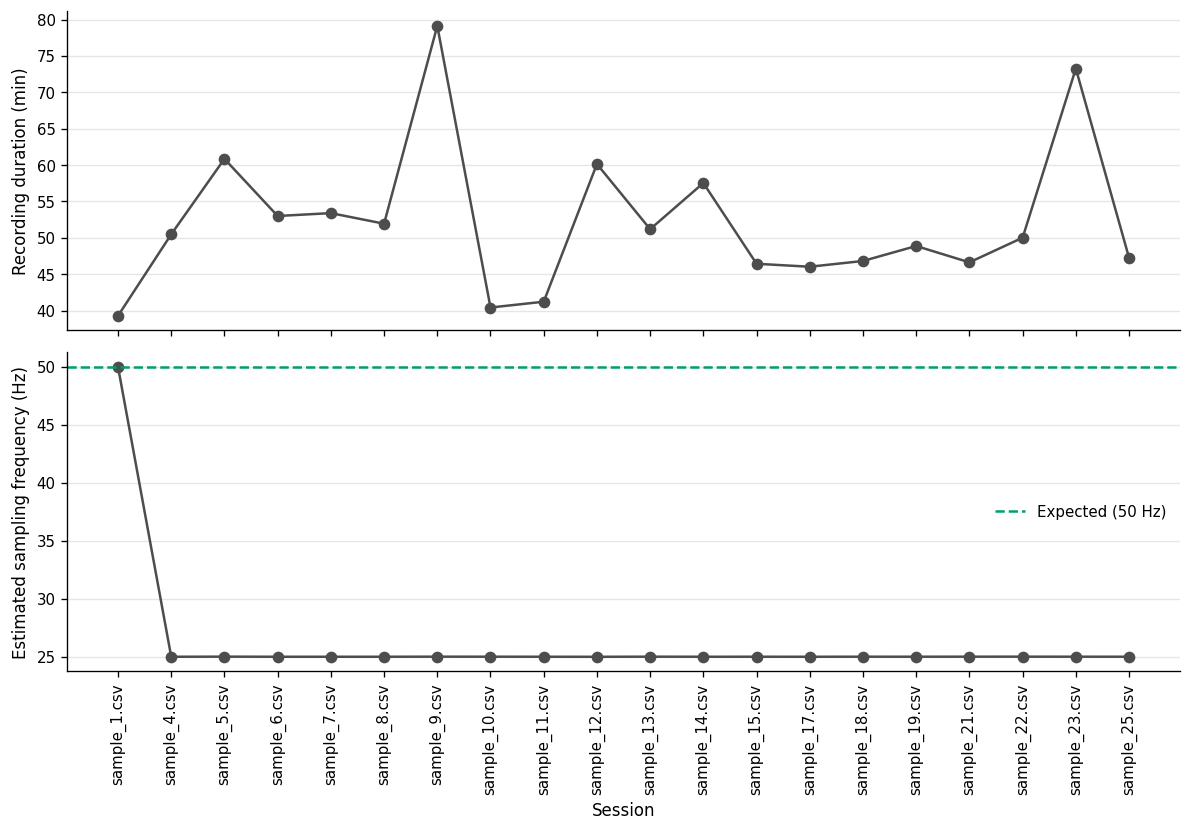

In [7]:
# Cell 6: Sampling and recording-duration plots
positions = np.arange(len(overview_table))
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(
    positions,
    overview_table["Duration (min)"],
    color="#4D4D4D",
    marker="o",
)
axes[0].set_ylabel("Recording duration (min)")
axes[0].grid(axis="y", color="0.9")
axes[1].plot(
    positions,
    overview_table["Estimated fs (Hz)"],
    color="#4D4D4D",
    marker="o",
)
axes[1].axhline(
    EXPECTED_FS,
    color=STATE_COLORS["Paired"],
    linestyle="--",
    label=f"Expected ({EXPECTED_FS:g} Hz)",
)
axes[1].set_ylabel("Estimated sampling frequency (Hz)")
axes[1].set_xlabel("Session")
axes[1].set_xticks(
    positions,
    overview_table["Session"],
    rotation=90,
)
axes[1].legend(frameon=False)
axes[1].grid(axis="y", color="0.9")
fig.tight_layout()
plt.show()

In [8]:
# Cell 7: Label statistics
dt_by_session = overview_table.set_index("Session")["Median dt (s)"]
label_rows = []
for item in sessions:
    frame = item["dataframe"]
    file_name = item["metadata"]["file_name"]
    labels = pd.to_numeric(frame["Label"], errors="coerce")
    sample_dt = dt_by_session[file_name]
    if not np.isfinite(sample_dt):
        sample_dt = EXPECTED_DT
    for label, state in LABEL_MAP.items():
        sample_count = int((labels == label).sum())
        label_rows.append({
            "Session": file_name,
            "State": state,
            "Samples": sample_count,
            "Duration (min)": sample_count * sample_dt / 60,
            "Percentage": 100 * sample_count / len(frame),
        })
label_table = pd.DataFrame(label_rows)
label_totals = (
    label_table.groupby("State", sort=False)
    .agg({"Samples": "sum", "Duration (min)": "sum"})
    .reset_index()
)
valid_samples = label_totals["Samples"].sum()
label_totals["Percentage"] = (
    100 * label_totals["Samples"] / valid_samples
)
display(label_totals.style.format({
    "Duration (min)": "{:.2f}",
    "Percentage": "{:.2f}",
}).hide(axis="index"))
display(label_table.pivot(
    index="Session",
    columns="State",
    values=["Samples", "Duration (min)", "Percentage"],
).style.format("{:.2f}"))

State,Samples,Duration (min),Percentage
Awake,1058769,680.00,65.35
Drowsy,561269,360.89,34.65


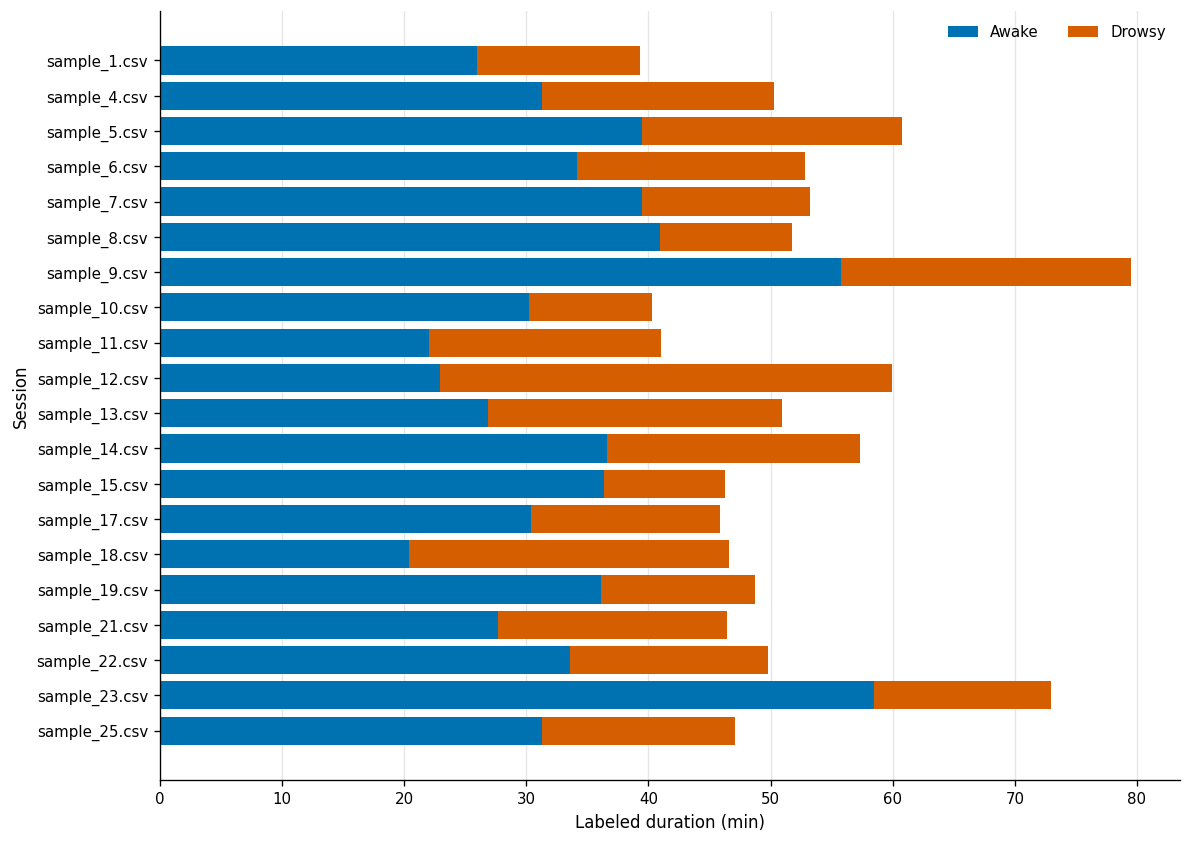

In [9]:
# Cell 8: Awake-Drowsy composition plot
duration_table = label_table.pivot(
    index="Session",
    columns="State",
    values="Duration (min)",
).reindex(overview_table["Session"])
positions = np.arange(len(duration_table))
figure_height = max(5, 0.28 * len(duration_table) + 1.5)
fig, ax = plt.subplots(figsize=(10, figure_height))
ax.barh(
    positions,
    duration_table["Awake"],
    color=STATE_COLORS["Awake"],
    label="Awake",
)
ax.barh(
    positions,
    duration_table["Drowsy"],
    left=duration_table["Awake"],
    color=STATE_COLORS["Drowsy"],
    label="Drowsy",
)
ax.set_yticks(positions, duration_table.index)
ax.invert_yaxis()
ax.set_xlabel("Labeled duration (min)")
ax.set_ylabel("Session")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="x", color="0.9")
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [10]:
# Cell 9: Continuous state segments
def extract_state_segments(item: dict) -> tuple[list[dict], int]:
    """Extract contiguous valid-label segments."""
    frame = item["dataframe"]
    file_name = item["metadata"]["file_name"]
    labels = pd.to_numeric(frame["Label"], errors="coerce")
    time_s = pd.to_numeric(frame["Time (s)"], errors="coerce")
    if frame.empty:
        return [], 0

    boundaries = [0]
    previous = labels.iloc[0]
    for index in range(1, len(labels)):
        current = labels.iloc[index]
        both_missing = pd.isna(current) and pd.isna(previous)
        if not both_missing and current != previous:
            boundaries.append(index)
        previous = current
    boundaries.append(len(labels))

    segments = []
    for segment_id, (start, stop) in enumerate(
        zip(boundaries, boundaries[1:]),
        start=1,
    ):
        label = labels.iloc[start]
        if label not in LABEL_MAP:
            continue
        end = stop - 1
        start_time = time_s.iloc[start]
        end_time = time_s.iloc[end]
        duration_s = np.nan
        if np.isfinite(start_time) and np.isfinite(end_time):
            duration_s = max(float(end_time - start_time), 0.0)
        segments.append({
            "Session": file_name,
            "Segment": segment_id,
            "State": LABEL_MAP[int(label)],
            "Start index": start,
            "End index": end,
            "Samples": stop - start,
            "Duration (s)": duration_s,
        })
    return segments, max(len(boundaries) - 2, 0)


segment_rows = []
transition_counts = {}
for item in sessions:
    session_segments, transitions = extract_state_segments(item)
    segment_rows.extend(session_segments)
    file_name = item["metadata"]["file_name"]
    transition_counts[file_name] = transitions
segment_table = pd.DataFrame(segment_rows)

segment_session_rows = []
for file_name in overview_table["Session"]:
    session_segments = segment_table[segment_table["Session"] == file_name]
    awake = session_segments.loc[
        session_segments["State"] == "Awake", "Duration (s)"
    ]
    drowsy = session_segments.loc[
        session_segments["State"] == "Drowsy", "Duration (s)"
    ]
    segment_session_rows.append({
        "Session": file_name,
        "Transitions": transition_counts[file_name],
        "Segments": len(session_segments),
        "Awake segments": len(awake),
        "Drowsy segments": len(drowsy),
        "Longest Awake (s)": awake.max(),
        "Longest Drowsy (s)": drowsy.max(),
        "Median Awake (s)": awake.median(),
        "Median Drowsy (s)": drowsy.median(),
    })
segment_session_table = pd.DataFrame(segment_session_rows)
segment_dataset_summary = pd.DataFrame([
    {
        "State": state,
        "Segments": int((segment_table["State"] == state).sum()),
        "Longest duration (s)": segment_table.loc[
            segment_table["State"] == state, "Duration (s)"
        ].max(),
        "Median duration (s)": segment_table.loc[
            segment_table["State"] == state, "Duration (s)"
        ].median(),
    }
    for state in ("Awake", "Drowsy")
])
print(f"Total transitions: {sum(transition_counts.values())}")
display(segment_dataset_summary.style.format({
    "Longest duration (s)": "{:.2f}",
    "Median duration (s)": "{:.2f}",
}).hide(axis="index"))
display(segment_session_table.style.format({
    column: "{:.2f}"
    for column in segment_session_table.columns
    if column.endswith("(s)")
}).hide(axis="index"))

Total transitions: 86


State,Segments,Longest duration (s),Median duration (s)
Awake,53,2460.47,660.36
Drowsy,53,1352.60,345.93


Session,Transitions,Segments,Awake segments,Drowsy segments,Longest Awake (s),Longest Drowsy (s),Median Awake (s),Median Drowsy (s)
sample_1.csv,7,8,4,4,1054.72,314.72,215.45,180.62
sample_4.csv,5,6,3,3,1178.45,829.13,700.40,201.53
sample_5.csv,5,6,3,3,1665.76,505.48,605.14,418.79
sample_6.csv,5,6,3,3,1152.22,544.02,904.18,428.11
sample_7.csv,3,4,2,2,1260.17,648.22,1189.25,412.45
sample_8.csv,3,4,2,2,1947.94,366.80,1232.97,325.06
sample_9.csv,3,4,2,2,1768.30,956.04,1660.42,713.19
sample_10.csv,3,4,2,2,1187.08,315.51,910.91,301.60
sample_11.csv,3,4,2,2,691.97,582.35,663.78,572.62
sample_12.csv,9,10,5,5,565.69,1352.60,303.33,318.75


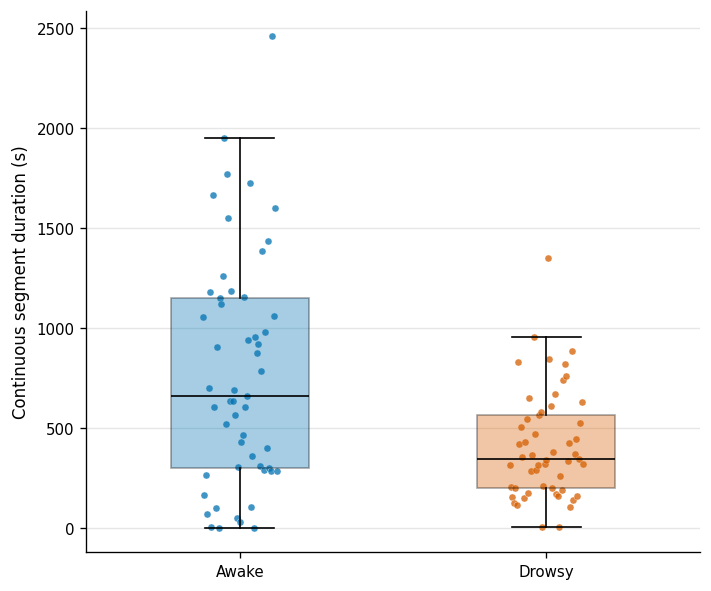

In [11]:
# Cell 10: Continuous segment-duration distribution
states = ["Awake", "Drowsy"]
segment_values = [
    segment_table.loc[
        segment_table["State"] == state,
        "Duration (s)",
    ].dropna().to_numpy()
    for state in states
]
fig, ax = plt.subplots(figsize=(6, 5))
boxplot = ax.boxplot(
    segment_values,
    positions=[1, 2],
    widths=0.45,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black"},
)
for patch, state in zip(boxplot["boxes"], states):
    patch.set_facecolor(STATE_COLORS[state])
    patch.set_alpha(0.35)
for position, state, values in zip([1, 2], states, segment_values):
    offsets = np.linspace(-0.12, 0.12, len(values))
    ax.scatter(
        position + offsets,
        values,
        color=STATE_COLORS[state],
        edgecolor="white",
        linewidth=0.3,
        s=18,
        alpha=0.75,
    )
ax.set_xticks([1, 2], states)
ax.set_ylabel("Continuous segment duration (s)")
ax.grid(axis="y", color="0.9")
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [12]:
# Cell 11: Window availability
availability_rows = []
session_availability_rows = []
for duration in WINDOW_DURATIONS:
    awake_eligible = 0
    drowsy_eligible = 0
    paired_eligible = 0
    for file_name in overview_table["Session"]:
        session_segments = segment_table[
            segment_table["Session"] == file_name
        ]
        awake_ok = bool((
            session_segments.loc[
                session_segments["State"] == "Awake",
                "Duration (s)",
            ] >= duration
        ).any())
        drowsy_ok = bool((
            session_segments.loc[
                session_segments["State"] == "Drowsy",
                "Duration (s)",
            ] >= duration
        ).any())
        paired_ok = awake_ok and drowsy_ok
        awake_eligible += awake_ok
        drowsy_eligible += drowsy_ok
        paired_eligible += paired_ok
        session_availability_rows.append({
            "Session": file_name,
            "Duration (s)": duration,
            "Awake eligible": awake_ok,
            "Drowsy eligible": drowsy_ok,
            "Paired eligible": paired_ok,
        })
    availability_rows.append({
        "Duration (s)": duration,
        "Awake eligible": awake_eligible,
        "Drowsy eligible": drowsy_eligible,
        "Paired eligible": paired_eligible,
    })
availability_table = pd.DataFrame(availability_rows)
session_availability = pd.DataFrame(session_availability_rows)
display(availability_table.style.hide(axis="index"))

Duration (s),Awake eligible,Drowsy eligible,Paired eligible
60,20,20,20
120,20,20,20
180,20,20,20
240,20,20,20
300,20,19,19


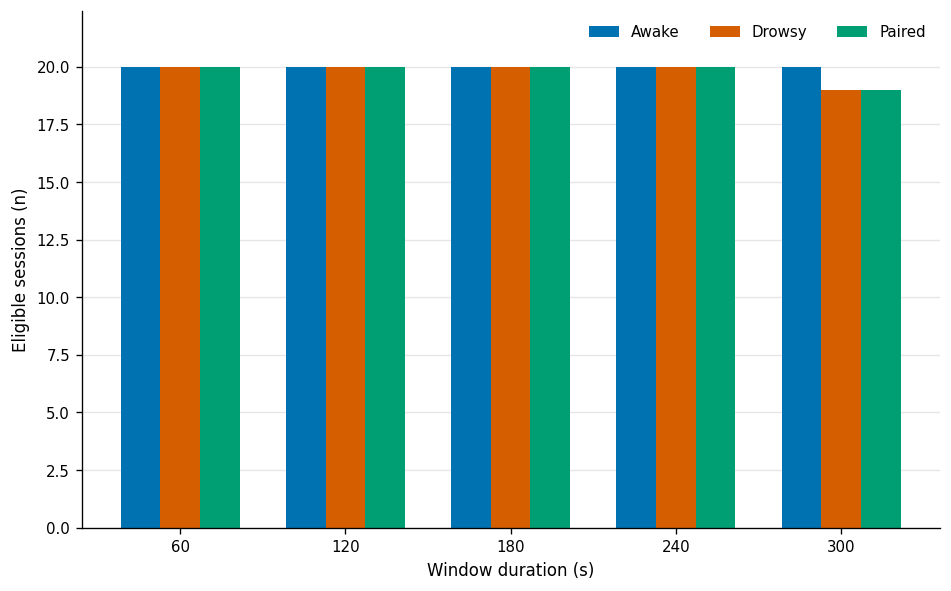

In [13]:
# Cell 12: Window availability plot
positions = np.arange(len(availability_table))
width = 0.24
fig, ax = plt.subplots(figsize=(8, 5))
for offset, state, column in [
    (-width, "Awake", "Awake eligible"),
    (0, "Drowsy", "Drowsy eligible"),
    (width, "Paired", "Paired eligible"),
]:
    ax.bar(
        positions + offset,
        availability_table[column],
        width=width,
        color=STATE_COLORS[state],
        label=state,
    )
ax.set_xticks(positions, availability_table["Duration (s)"])
ax.set_xlabel("Window duration (s)")
ax.set_ylabel("Eligible sessions (n)")
ax.set_ylim(0, len(sessions) * 1.12)
ax.legend(frameon=False, ncol=3)
ax.grid(axis="y", color="0.9")
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [14]:
# Cell 13: Final dataset summary
excluded_sessions = len(load_failures)
final_usable_sessions = len(sessions)
awake_minutes = label_totals.loc[
    label_totals["State"] == "Awake", "Duration (min)"
].iloc[0]
drowsy_minutes = label_totals.loc[
    label_totals["State"] == "Drowsy", "Duration (min)"
].iloc[0]
sampling_rates = overview_table["Estimated fs (Hz)"].dropna()
final_summary = pd.DataFrame({
    "Metric": [
        "Original sessions",
        "Excluded sessions",
        "Final usable sessions",
        "Total recording hours",
        "Awake duration (h)",
        "Drowsy duration (h)",
        "Sampling fs min / median / max (Hz)",
    ],
    "Value": [
        len(csv_paths),
        excluded_sessions,
        final_usable_sessions,
        f"{total_recording_hours:.2f}",
        f"{awake_minutes / 60:.2f}",
        f"{drowsy_minutes / 60:.2f}",
        (
            f"{sampling_rates.min():.2f} / "
            f"{sampling_rates.median():.2f} / "
            f"{sampling_rates.max():.2f}"
        ),
    ],
})
print(
    "Exclusion rule: sessions are excluded only when loading fails "
    "or the CSV contains no data rows."
)
display(final_summary.style.hide(axis="index"))
display(availability_table.style.hide(axis="index"))
if load_failures:
    display(pd.DataFrame(load_failures).style.hide(axis="index"))

Exclusion rule: sessions are excluded only when loading fails or the CSV contains no data rows.


Metric,Value
Original sessions,20
Excluded sessions,0
Final usable sessions,20
Total recording hours,17.40
Awake duration (h),11.33
Drowsy duration (h),6.01
Sampling fs min / median / max (Hz),24.99 / 25.00 / 50.00


Duration (s),Awake eligible,Drowsy eligible,Paired eligible
60,20,20,20
120,20,20,20
180,20,20,20
240,20,20,20
300,20,19,19
